In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('temperatures.csv')
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [3]:
df.isnull().sum()

Date    0
Temp    0
dtype: int64

In [4]:
temperature_values = df['Temp'].unique()
temperature_values

array([20.7, 17.9, 18.8, 14.6, 15.8, 17.4, 21.8, 20. , 16.2, 13.3, 16.7,
       21.5, 25. , 20.6, 24.8, 17.7, 15.5, 18.2, 12.1, 14.4, 16. , 16.5,
       18.7, 19.4, 17.2, 15.1, 15.4, 15.3, 21.9, 19.9, 16.6, 16.8, 17.1,
       15. , 13.7, 13.9, 18.3, 22. , 22.1, 21.2, 18.4, 16.1, 15.7, 18.5,
       16.9, 17.5, 17.8, 18.6, 17. , 14.3, 11.4, 16.3, 11.8, 12.2, 14.7,
       11.3, 10.6, 11.7, 14.2, 11.2,  8.1,  8. ,  8.8, 13.4, 10.9, 11. ,
       14.5, 18.1, 10. , 14.9, 15.9, 13. ,  7.6, 11.5, 13.5, 12.4, 13.2,
       13.8,  9. ,  9.8,  8.9,  7.4,  9.9,  9.3,  8.6, 11.9, 14. , 12. ,
       10.5, 10.7, 10.1,  5.3,  6.6,  8.5,  5.9,  3.2,  2.1,  3.4,  5.4,
        9.6, 12.3, 12.6, 12.8, 11.6,  5.7,  7.1,  2.5,  3.5,  4.6,  7.7,
       10.4,  9.2,  6.1,  2.7,  4.3,  6.3,  3.8,  4.4,  4.8,  5.8,  6.2,
        7.3, 10.2,  9.5,  6.5,  7. ,  8.3,  6.8,  7.2,  5. ,  6.9,  5.2,
        3. ,  5.6,  7.9, 10.3,  9.7, 12.5,  3.9,  6. ,  5.5,  7.5,  7.8,
       14.1, 12.9,  9.1,  8.4, 13.6,  9.4, 14.8, 16

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   str    
 1   Temp    3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 57.2 KB


In [6]:
df.describe()

,Temp
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [9]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'].dt.year.unique()

array([1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990],
      dtype=int32)

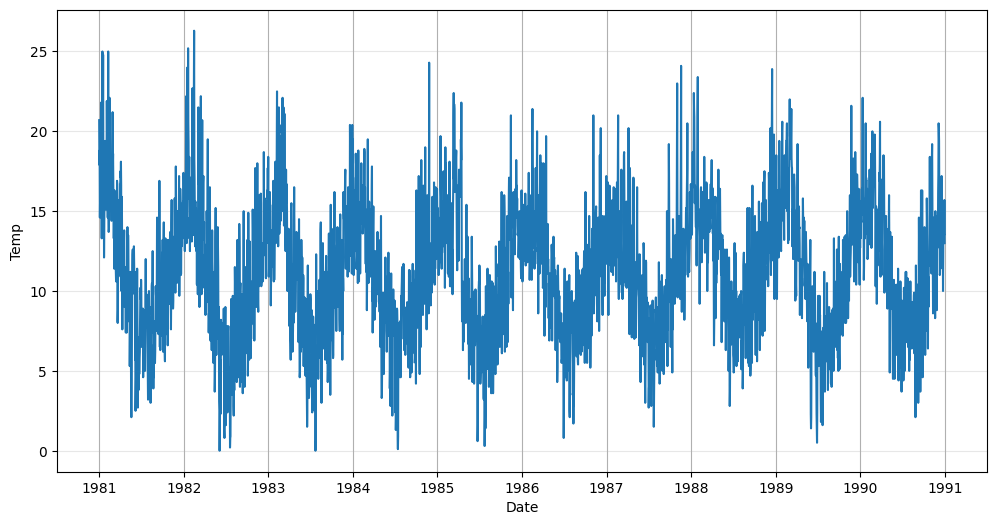

In [10]:
plt.figure(figsize=(12,6))
sns.lineplot(x=df['Date'], y=df['Temp'])
plt.grid(axis='x')
plt.grid(axis='y', alpha=0.3)
plt.show()

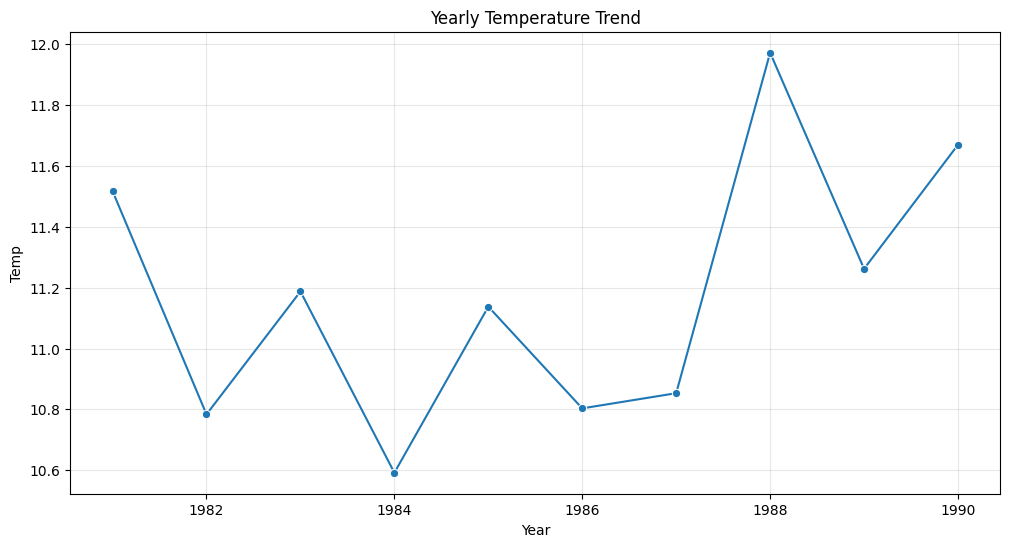

In [19]:
df['Year'] = df['Date'].dt.year
trend = df.groupby('Year')['Temp'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Temp', data=trend, marker='o')

plt.title("Yearly Temperature Trend")
plt.grid(alpha=0.3)
plt.show()

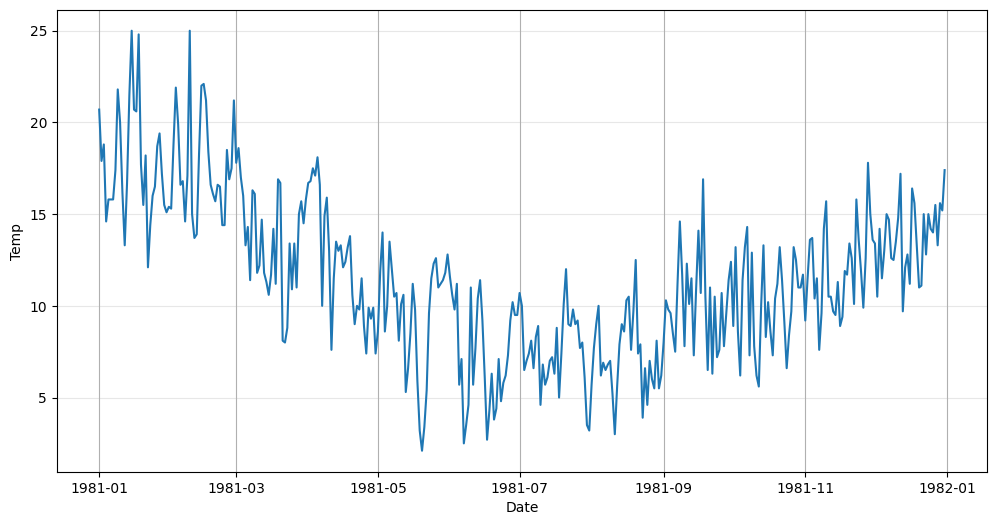

In [22]:
df_1981 = df[df['Date'].dt.year == 1981]
plt.figure(figsize=(12,6))
sns.lineplot(x=df_2023['Date'], y=df_2023['Temp'])
plt.grid(axis='x')
plt.grid(axis='y', alpha=0.3)
plt.show()

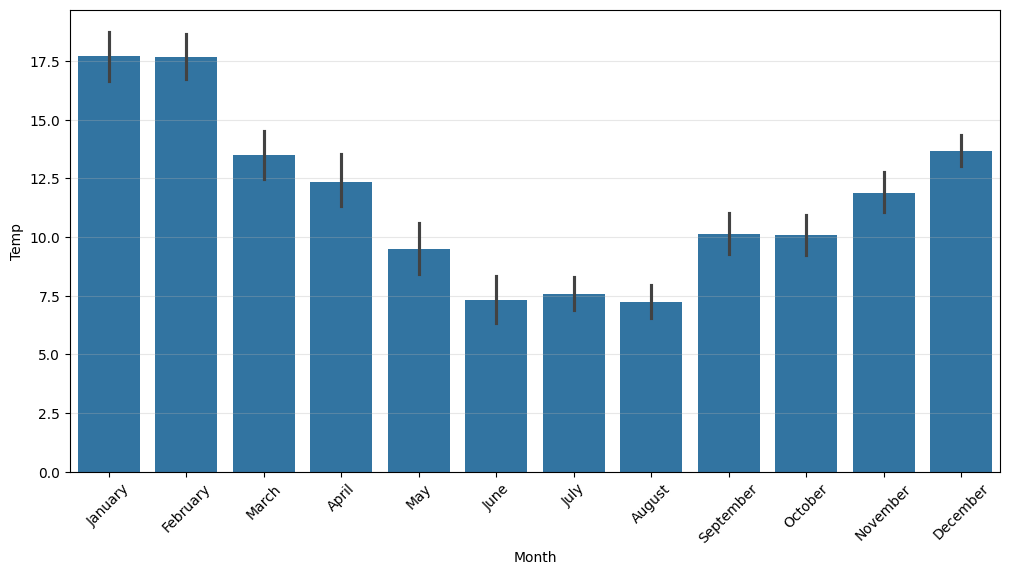

In [23]:
df_1981['Month'] = df_1981['Date'].dt.month_name()
plt.figure(figsize=(12,6))
sns.barplot(data=df_1981, x='Month', y='Temp', estimator='mean')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [25]:
##A lag feature is the value from N days ago. lag_1 = yesterday's temperature. 
##This gives the model "memory" — it can learn that cold days often follow cold days (autocorrelation). 
##The first N rows get NaN because there's no prior data yet.
for lag in [1, 2, 3, 7]:
    df[f'lag_{lag}'] = df['Temp'].shift(lag)

df.head(20)

In [ ]:
##df.dropna()  # remove rows with NaN from lag

In [29]:
##Rolling window = summary of the recent past (a trend lens)
##Rolling stats → “What’s the recent behavior pattern?”
w = 7
df['roll_mean'] = df['Temp'].rolling(window=w).mean()
df['roll_std']  = df['Temp'].rolling(window=w).std()
df['roll_min']  = df['Temp'].rolling(window=w).min()
df['roll_max']  = df['Temp'].rolling(window=w).max()

In [30]:
df.head(20)

,Date,Temp,Year,lag_1,lag_2,lag_3,lag_7,roll_mean,roll_std,roll_min,roll_max
0,1981-01-01,20.7,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1981-01-02,17.9,1981,20.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1981-01-03,18.8,1981,17.9,20.7,NaN,NaN,NaN,NaN,NaN,NaN
3,1981-01-04,14.6,1981,18.8,17.9,20.7,NaN,NaN,NaN,NaN,NaN
4,1981-01-05,15.8,1981,14.6,18.8,17.9,NaN,NaN,NaN,NaN,NaN
5,1981-01-06,15.8,1981,15.8,14.6,18.8,NaN,NaN,NaN,NaN,NaN
6,1981-01-07,15.8,1981,15.8,15.8,14.6,NaN,17.057143,2.152407,14.6,20.7
7,1981-01-08,17.4,1981,15.8,15.8,15.8,20.7,16.585714,1.476966,14.6,18.8
8,1981-01-09,21.8,1981,17.4,15.8,15.8,17.9,17.142857,2.462287,14.6,21.8
9,1981-01-10,20.0,1981,21.8,17.4,15.8,18.8,17.314286,2.632761,14.6,21.8


In [31]:
##Extract structural information from the date itself: month, day-of-week, season, quarter.
df['month']       = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['quarter']      = df['Date'].dt.quarter
df['season']      = df['month'].map({12:'Summer',1:'Summer',2:'Summer',
                           3:'Autumn',4:'Autumn',5:'Autumn',
                           6:'Winter',7:'Winter',8:'Winter',
                           9:'Spring',10:'Spring',11:'Spring'})

In [32]:
df.head(20)

,Date,Temp,Year,lag_1,lag_2,lag_3,lag_7,roll_mean,roll_std,roll_min,roll_max,month,day_of_week,quarter,season
0,1981-01-01,20.7,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,Summer
1,1981-01-02,17.9,1981,20.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,4,1,Summer
2,1981-01-03,18.8,1981,17.9,20.7,NaN,NaN,NaN,NaN,NaN,NaN,1,5,1,Summer
3,1981-01-04,14.6,1981,18.8,17.9,20.7,NaN,NaN,NaN,NaN,NaN,1,6,1,Summer
4,1981-01-05,15.8,1981,14.6,18.8,17.9,NaN,NaN,NaN,NaN,NaN,1,0,1,Summer
5,1981-01-06,15.8,1981,15.8,14.6,18.8,NaN,NaN,NaN,NaN,NaN,1,1,1,Summer
6,1981-01-07,15.8,1981,15.8,15.8,14.6,NaN,17.057143,2.152407,14.6,20.7,1,2,1,Summer
7,1981-01-08,17.4,1981,15.8,15.8,15.8,20.7,16.585714,1.476966,14.6,18.8,1,3,1,Summer
8,1981-01-09,21.8,1981,17.4,15.8,15.8,17.9,17.142857,2.462287,14.6,21.8,1,4,1,Summer
9,1981-01-10,20.0,1981,21.8,17.4,15.8,18.8,17.314286,2.632761,14.6,21.8,1,5,1,Summer


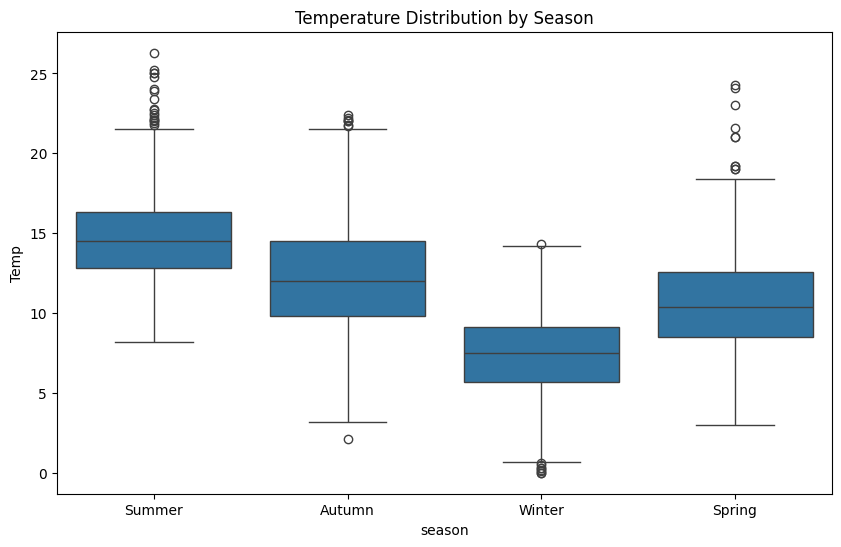

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x='season', y='Temp', data=df)
plt.title("Temperature Distribution by Season")
plt.show()

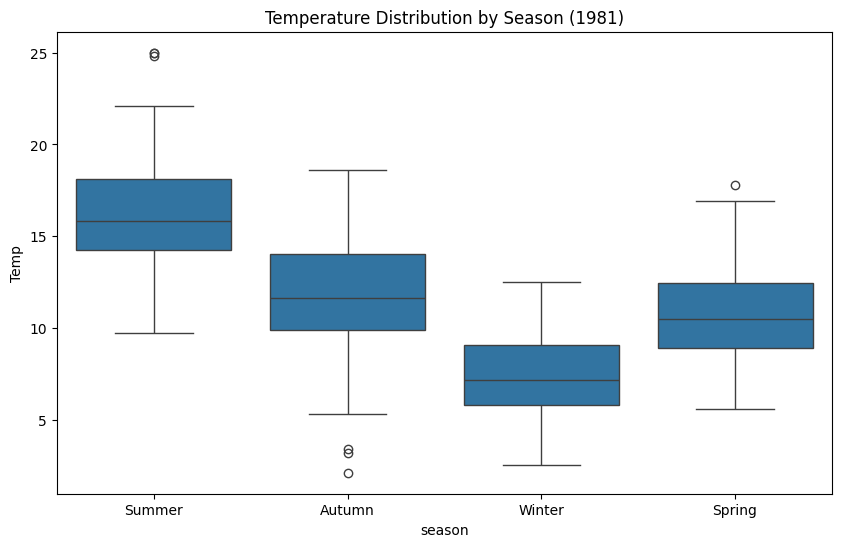

In [34]:
df_1981 = df[df['Year'] == 1981]
plt.figure(figsize=(10,6))

sns.boxplot(x='season', y='Temp', data=df_1981)

plt.title("Temperature Distribution by Season (1981)")
plt.show()

In [35]:
##text
texts = [
    "I love machine learning",
    "Machine learning is fun",
    "I hate bugs",
    "Debugging is fun"
]
##bag of words
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

print("Features:", vectorizer.get_feature_names_out())
print("Shape:", X.shape)
print(X.toarray())

Features: ['bugs' 'debugging' 'fun' 'hate' 'is' 'learning' 'love' 'machine']
Shape: (4, 8)
[[0 0 0 0 0 1 1 1]
 [0 0 1 0 1 1 0 1]
 [1 0 0 1 0 0 0 0]
 [0 1 1 0 1 0 0 0]]


In [36]:
from PIL import Image
import numpy as np

# Load image
img = Image.open("dog.jpg")  # put any image file here

# Resize (important feature engineering step)
img_resized = img.resize((64, 64))

# Convert to array (features = pixels)
img_array = np.array(img_resized)

print(img_array.shape)

(64, 64, 3)


In [37]:
features = img_array.flatten()

print(features.shape)  # 64*64*3 = 12288 features (if RGB)
print(features[:10])   # first few pixel values

(12288,)
[ 84  67  12 102  73  12 177 120  13 219]
